<a href="https://colab.research.google.com/github/Bus-RaRa/deeplearningcode2/blob/main/Random_sampling.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Random Sampling and Sampling Variability

In [3]:
import numpy as np
import matplotlib.pyplot as plt
import torch

In [4]:
#create a list of numbers to compute the mean and variance of
x = [1,2,5,4,6,7,8,4,35,5,6,6,7,9,10,44,3,3,2,4,2]
n = len(x)

#computate the population mean
popmean = np.mean(x)

#computate a sample mean
sample = np.random.choice(x,size=5,replace=True)
sampmean = np.mean(sample)

print(popmean)
print(sampmean)

8.238095238095237
4.2


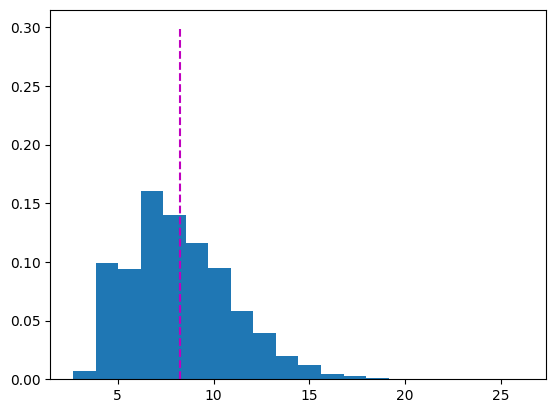

In [5]:
#computate lots of sample means

#number of experiments to run
nExpers = 100000

#run the experiments
sampleMeans = np.zeros(nExpers)
for i in range(nExpers):
    sample = np.random.choice(x,size=15,replace=True)
    sampleMeans[i] = np.mean(sample)
plt.hist(sampleMeans,bins=20,density=True)
plt.plot([popmean,popmean],[0,.3],'m--')
plt.show()

#Seeding

In [6]:
np.random.seed(17)
print(np.random.rand(5))
print(np.random.rand(5))
#[0.294665   0.53058676 0.19152079 0.06790036 0.78698546]
#[0.65633352 0.6375209  0.57560289 0.03906292 0.3578136 ]

[0.294665   0.53058676 0.19152079 0.06790036 0.78698546]
[0.65633352 0.6375209  0.57560289 0.03906292 0.3578136 ]


In [7]:
#New seed code in Numpy
randseed1 = np.random.RandomState(17) #creates a local scope for the seeding

In [8]:
#in Pytorch
torch.randn(5)

tensor([ 0.0909, -0.4004, -0.8817, -0.8399, -0.5634])

In [9]:
torch.manual_seed(17)
print(torch.randn(5))

#torch's seed doesn't spread to numpy
print(np.random.randn(5))

tensor([-1.4135,  0.2336,  0.0340,  0.3499, -0.0145])
[ 0.14867505 -0.43778315  2.171257    1.15231025 -1.81881234]


#T-TEST

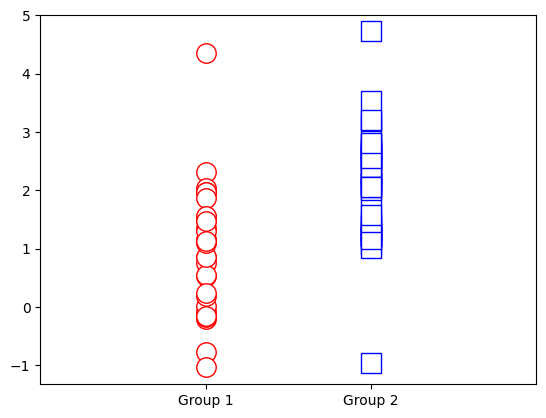

In [10]:
import scipy.stats as stats
# parameters
n1 = 30   # samples in dataset 1
n2 = 40   # ...and 2
mu1 = 1   # population mean in dataset 1
mu2 = 2   # population mean in dataset 2

# generate the data
data1 = mu1 + np.random.randn(n1)
data2 = mu2 + np.random.randn(n2)



# plot them
plt.plot(np.zeros(n1),data1,'ro',markerfacecolor='w',markersize=14)
plt.plot(np.ones(n2), data2,'bs',markerfacecolor='w',markersize=14)
plt.xlim([-1,2])
plt.xticks([0,1],labels=['Group 1','Group 2'])
plt.show()

In [11]:
# t-test via stats package

# _ind = independent samples
t,p = stats.ttest_ind(data1,data2)
print(t)
print(p)

-4.604158692558216
1.8673994396183396e-05


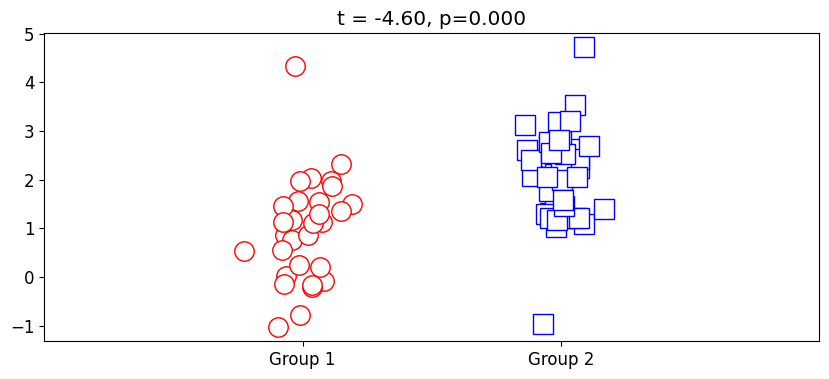

In [12]:
# common way to show t-test results in a plot
fig = plt.figure(figsize=(10,4))
plt.rcParams.update({'font.size':12}) # change the font size

plt.plot(0+np.random.randn(n1)/15, data1, 'ro',markerfacecolor='w',markersize=14)
plt.plot(1+np.random.randn(n2)/15, data2, 'bs',markerfacecolor='w',markersize=14)
plt.xlim([-1,2])
plt.xticks([0,1],labels=['Group 1','Group 2'])

# set the title to include the t-value and p-value
plt.title(f't = {t:.2f}, p={p:.3f}')

plt.show()